In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc


In [4]:
df=pd.read_csv('LICI - minute ata.csv')

In [5]:
df.head()

,date,open,high,low,close,volume
0,2022-05-17 09:44:00+05:30,872.0,872.0,872.0,872.0,3759243
1,2022-05-17 09:45:00+05:30,872.0,872.0,872.0,872.0,0
2,2022-05-17 09:46:00+05:30,872.0,872.0,872.0,872.0,0
3,2022-05-17 09:47:00+05:30,872.0,872.0,872.0,872.0,0
4,2022-05-17 09:48:00+05:30,872.0,872.0,872.0,872.0,0


In [6]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [7]:
df['Price_Movement'] = np.where(df['close']>df['open'],1,0)

In [8]:
X = df[['open', 'high', 'low', 'volume']]
y = df['Price_Movement']

In [9]:
X.isnull().sum()

open      0
high      0
low       0
volume    0
dtype: int64

In [10]:

X.fillna(X.mean(), inplace=True)

C:\Users\jayas\AppData\Local\Temp\ipykernel_31052\3376847072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [13]:
model= LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [14]:
y_pred=model.predict(X_test)

In [15]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.5797704447632711
Precision: 1.0
Recall: 0.03746302990469931
F1 Score: 0.0722204624643649


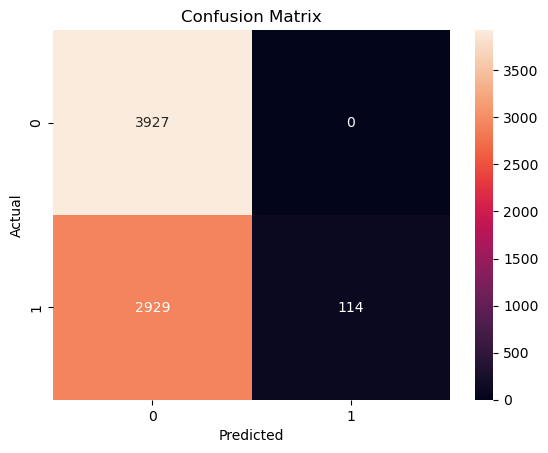

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

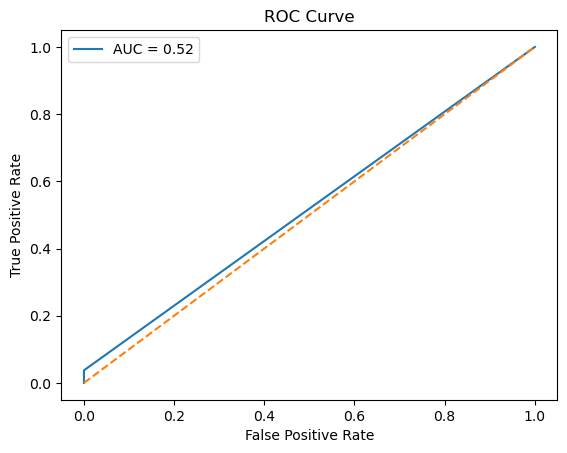

In [20]:
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

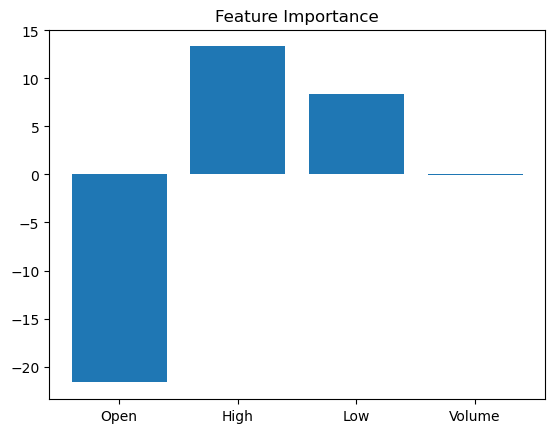

In [21]:
# Feature Importance
importance = model.coef_[0]
features = ['Open','High','Low','Volume']

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()


In [22]:
model_l2 = LogisticRegression(C=0.5, penalty='l2')
model_l2.fit(X_train, y_train)

print("Optimized Model Accuracy:", accuracy_score(y_test, model_l2.predict(X_test)))

Optimized Model Accuracy: 0.5672883787661406
